# Prediction of Parkinson's Disease Using Artificial Neural Networks

***

**Team Members:**
- OUAJIH Badr Eddine
- DAOUDI Sara
- ALAHYANE Youssef
- BEN HAMMADI Fatima Zahrae

**Objective:** an ANN model that predicts whether a person has Parkinson's disease based on biomedical voice measurements.
This notebook covers ANN architecture, activation functions, dropout/overfitting, loss functions, SGD optimization, and the vanishing gradient problem.


## Data and Preprocessing

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure figures dir exists
os.makedirs('./figures', exist_ok=True)

# 1. Load Dataset
df = pd.read_csv('./data/parkinsons.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [18]:
# 2. Inspect Data Types and Null Values
df.info()
print("\nMissing values:\n", df.isnull().sum().max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

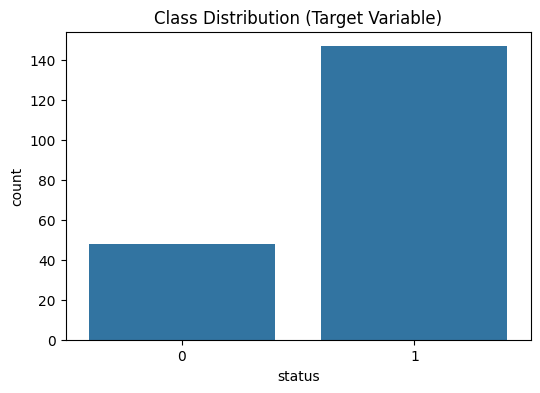

Class distribution:
 status
1    0.753846
0    0.246154
Name: proportion, dtype: float64


In [19]:
# 3. Class Balance (status: 1 = Parkinson's, 0 = Healthy)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='status')
plt.title('Class Distribution (Target Variable)')
plt.savefig('./figures/class_distribution.png')
plt.show()

print("Class distribution:\n", df['status'].value_counts(normalize=True))

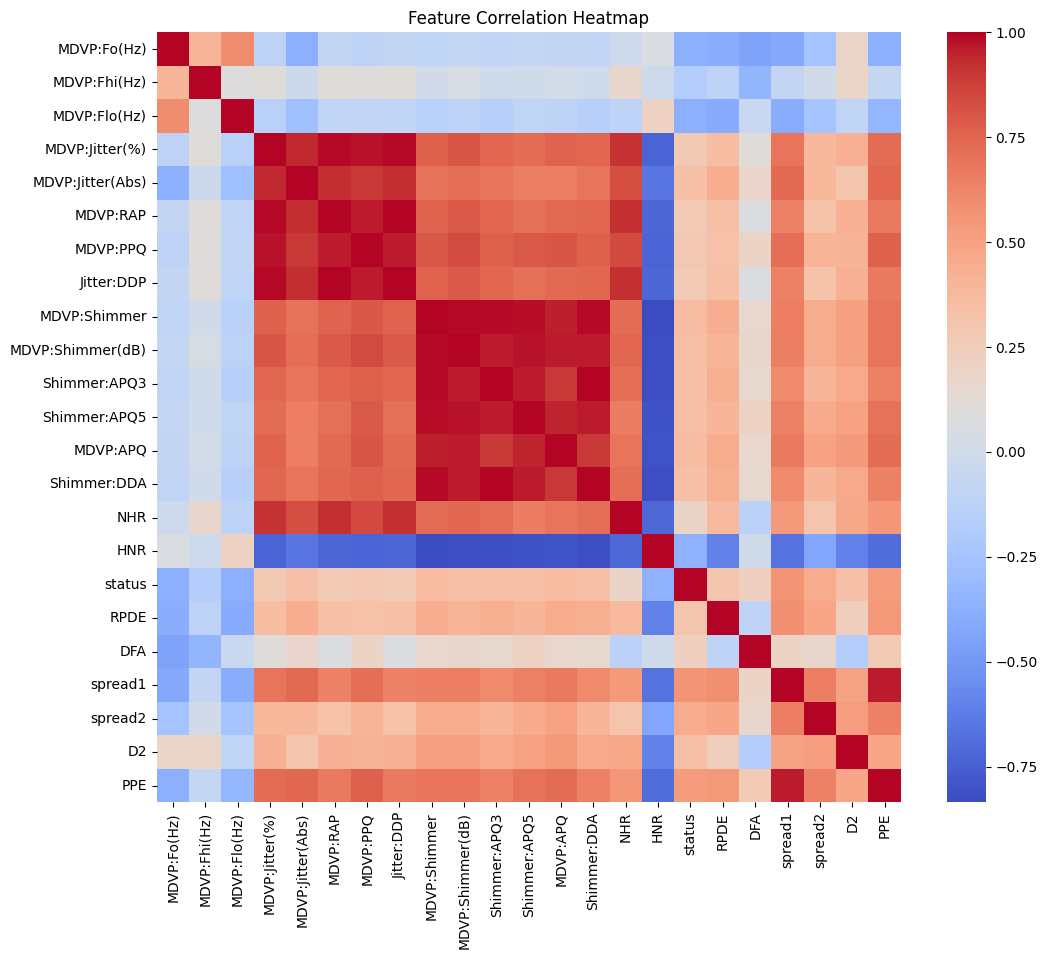

In [20]:
# 4. Correlation Heatmap
plt.figure(figsize=(12, 10))
# Drop string columns like 'name'
numeric_df = df.drop(columns=['name'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('./figures/correlation_heatmap.png')
plt.show()

In [21]:
# 5. Preprocessing (Scaling & Splitting)
# Separate X and y
X = numeric_df.drop(columns=['status'])
y = numeric_df['status']

# Recommended split: 70% training, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train size: 136
Validation size: 29
Test size: 30


In [22]:
# Categorical labels for Experiment 2 (Categorical Crossentropy)
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=2)
y_val_cat = to_categorical(y_val, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

## Modeling and Experiments

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

### Phase 5 — Baseline ANN Model
- **Hidden Layer 1:** 16 neurons, ReLU
- **Hidden Layer 2:** 8 neurons, ReLU
- **Output Layer:** 1 neuron, Sigmoid (since binary classification)
- **Optimizer:** SGD
- **Loss:** binary_crossentropy

In [24]:
def build_baseline():
    model = Sequential([
        Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=SGD(learning_rate=0.01),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

baseline_model = build_baseline()
history_baseline = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100, batch_size=8, verbose=0
)

print("Baseline model trained.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline model trained.


### Phase 6, Main Experiments

#### Experiment 1 — Compare Activation Functions
Comparing `ReLU`, `sigmoid`, and `tanh` in the hidden layers.

In [25]:
def build_model_activation(activation_func):
    model = Sequential([
        Dense(16, activation=activation_func, input_shape=(X_train.shape[1],)),
        Dense(8, activation=activation_func),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model

results_activations = {}
for act in ['relu', 'sigmoid', 'tanh']:
    print(f"Training with {act}...")
    model = build_model_activation(act)
    history = model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=8, verbose=0)
    results_activations[act] = history

Training with relu...
Training with sigmoid...
Training with tanh...


#### Experiment 2 — Compare Loss Functions
(A) `binary_crossentropy` (Best suited)
(B) `mse` (Less suitable)
(C) `categorical_crossentropy` (Requires one-hot encoding)

In [26]:
results_loss = {}

# A. Binary Crossentropy
model_bce = build_baseline()
hist_bce = model_bce.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=8, verbose=0)
results_loss['binary_crossentropy'] = hist_bce

# B. Mean Squared Error (MSE)
model_mse = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_mse.compile(optimizer=SGD(learning_rate=0.01), loss='mse', metrics=['accuracy'])
hist_mse = model_mse.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=8, verbose=0)
results_loss['mse'] = hist_mse

# C. Categorical Crossentropy (2 Output neurons, Softmax)
model_cce = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(2, activation='softmax')
])
model_cce.compile(optimizer=SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
hist_cce = model_cce.fit(X_train_scaled, y_train_cat, validation_data=(X_val_scaled, y_val_cat), epochs=100, batch_size=8, verbose=0)
results_loss['categorical_crossentropy'] = hist_cce

#### Experiment 3 — Overfitting & Dropout
Comparing model without dropout and with `Dropout(0.3)` to demonstrate overfitting control.

In [27]:
def build_dropout_model():
    model = Sequential([
        Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_dropout = build_dropout_model()
hist_dropout = model_dropout.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=150, batch_size=8, verbose=0)

# The baseline model (from earlier) is our "without dropout" comparison
hist_no_dropout = baseline_model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=150, batch_size=8, verbose=0)

#### Experiment 4 — Effect of Depth (Vanishing Gradient discussion)
1 Hidden Layer vs 3 Hidden Layers

In [28]:
# Shallow (1 Hidden Layer)
model_shallow = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])
model_shallow.compile(optimizer=SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
hist_shallow = model_shallow.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=8, verbose=0)

# Deep (4 Hidden Layers)
# Using sigmoid across deep network to force vanishing gradient
model_deep = Sequential([
    Dense(16, activation='sigmoid', input_shape=(X_train.shape[1],)),
    Dense(16, activation='sigmoid'),
    Dense(16, activation='sigmoid'),
    Dense(8, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])
model_deep.compile(optimizer=SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
hist_deep = model_deep.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=8, verbose=0)

## Evaluation, report integration, presentation

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Evaluate Best Recommended Model (Dropout Model) on Test Set
y_test_pred_prob = model_dropout.predict(X_test_scaled)
y_test_pred = (y_test_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("=== BEST MODEL TEST SET PERFORMANCE (With Dropout) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
=== BEST MODEL TEST SET PERFORMANCE (With Dropout) ===
Accuracy : 0.8667
Precision: 0.8462
Recall   : 1.0000
F1 Score : 0.9167


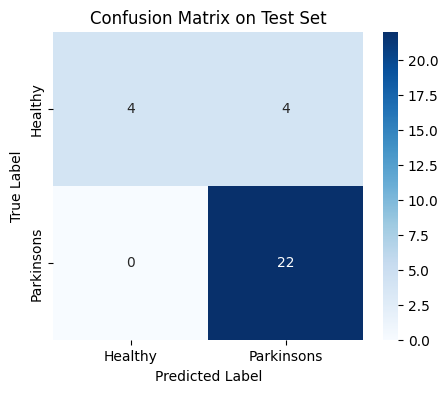

In [30]:
# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Parkinsons'], yticklabels=['Healthy', 'Parkinsons'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix on Test Set')
plt.savefig('./figures/confusion_matrix.png')
plt.show()

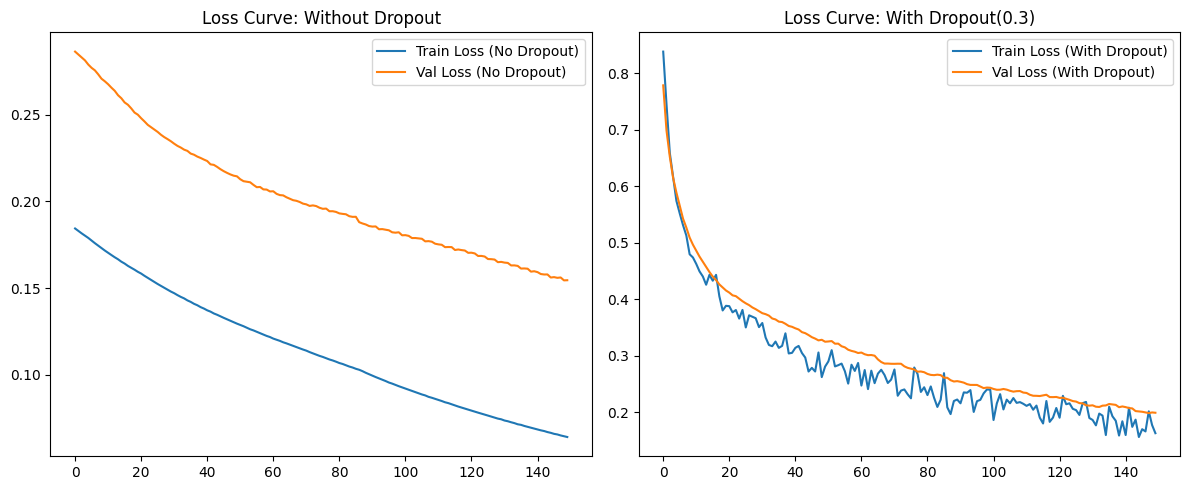

In [31]:
# Plot Overfitting Comparison (Experiment 3)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_no_dropout.history['loss'], label='Train Loss (No Dropout)')
plt.plot(hist_no_dropout.history['val_loss'], label='Val Loss (No Dropout)')
plt.title('Loss Curve: Without Dropout')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_dropout.history['loss'], label='Train Loss (With Dropout)')
plt.plot(hist_dropout.history['val_loss'], label='Val Loss (With Dropout)')
plt.title('Loss Curve: With Dropout(0.3)')
plt.legend()

plt.tight_layout()
plt.savefig('./figures/loss_curve.png')
plt.show()

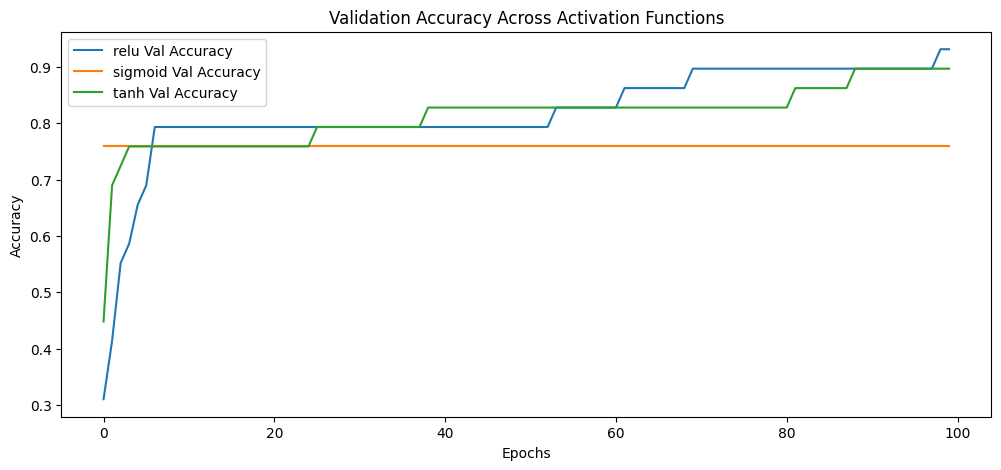

In [32]:
# Plot Accuracy Curves for Activation Functions (Experiment 1)
plt.figure(figsize=(12, 5))
for act in ['relu', 'sigmoid', 'tanh']:
    plt.plot(results_activations[act].history['val_accuracy'], label=f'{act} Val Accuracy')

plt.title('Validation Accuracy Across Activation Functions')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('./figures/accuracy_curve.png')
plt.show()